<a href="https://colab.research.google.com/github/HazemWaelll/Diabetes-Prediction/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Diabetes Prediction

## Project Overview

In this project, we will build and compare several classification models to predict whether a person has diabetes based on different health-related features.

The classification models used in this project are:

* Logistic Regression
* K-Nearest Neighbors (KNN)
* Support Vector Machine (SVM)
* Kernel SVM
* Naive Bayes
* Decision Tree
* Random Forest

The models will be evaluated using appropriate classification metrics, and their performance will be compared to determine which models perform best on the diabetes classification task.

# 📊 Dataset

The dataset used in this project contains health-related information about individuals, including features such as glucose level, blood pressure, Body Mass Index (BMI), insulin, age, and other medical measurements.

**Target variable:** `Outcome`

The goal is to predict `Outcome` using the available features and determine whether an individual is likely to have diabetes.

**Dataset source:**

https://www.kaggle.com/datasets/salihacur/diabetes

# Importing libraries

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Importing dataset

In [38]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Understanding the data

In [39]:
df.shape

(768, 9)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [41]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [42]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non-Diabetic

1 --> Diabetic

In [43]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [44]:
df.duplicated().sum()

np.int64(0)

# Checking invalid zero values

In [45]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


# Separating X and y

In [46]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

# Splitting the dataset into the Training set and Test set

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (576, 8)
Test set: (192, 8)


# Detect outliers

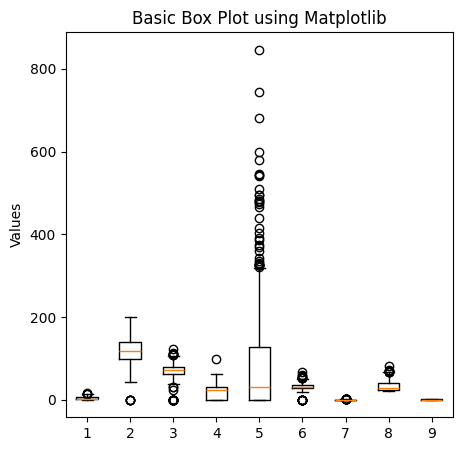

In [48]:
plt.figure(figsize=(5, 5))
plt.boxplot(df)
plt.title("Basic Box Plot using Matplotlib")
plt.ylabel("Values")
plt.show()

In [49]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    return df

numerical_cols = [col for col in df.select_dtypes(include=np.number).columns if col != 'Outcome']

for column in numerical_cols:
    df = cap_outliers_iqr(df, column)

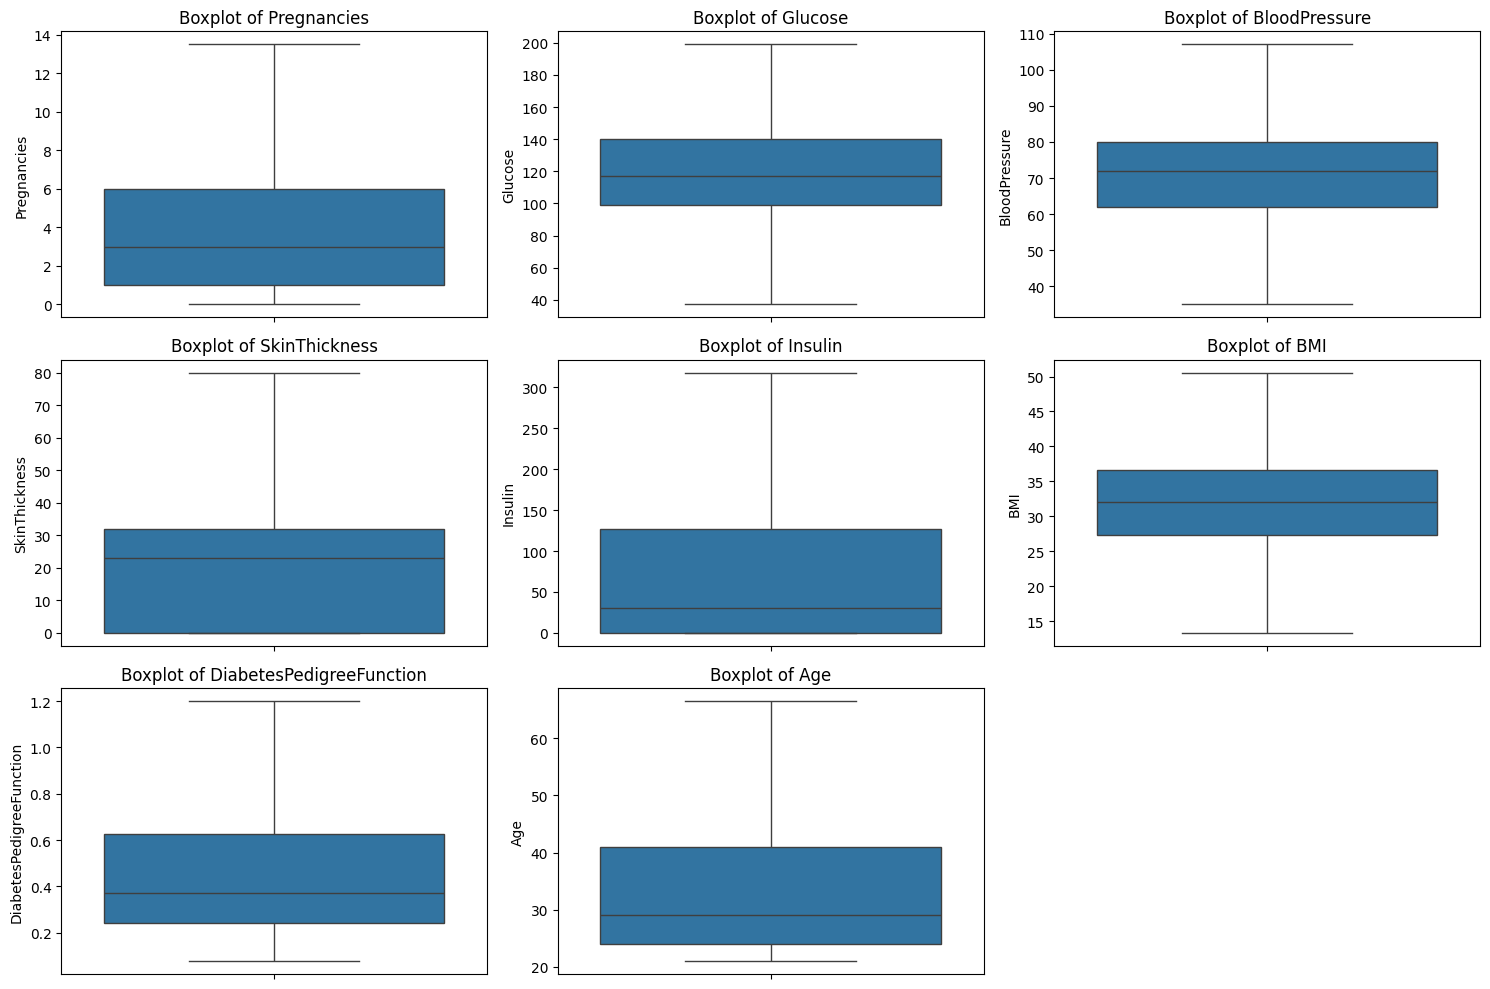

In [50]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Handling nan values

In [51]:
df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [52]:
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Feature scaling

Scaling is useful for:
- Logistic Regression
- KNN
- SVM
- Kernel SVM

It is not necessary for:

- Naive Bayes
- Decision Tree
- Random Forest

In [53]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_imputed)
X_test_scaled = sc.transform(X_test_imputed)

# Training models

## Logistic Regression

In [54]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)
logistic_pred = logistic_model.predict(X_test_scaled)
logistic_acc = accuracy_score(y_test, logistic_pred)
print("Logistic Regression Accuracy:", logistic_acc)

Logistic Regression Accuracy: 0.7291666666666666


## KNN

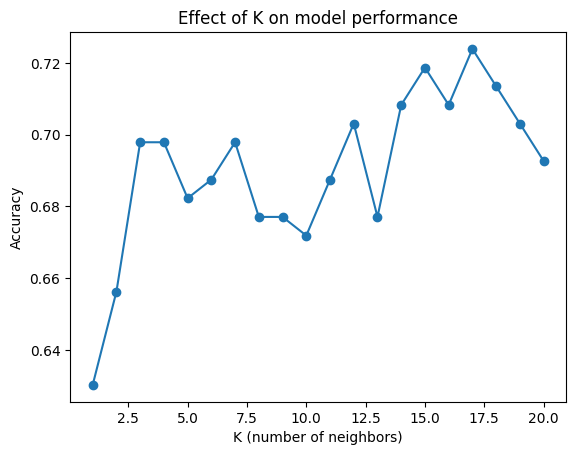

Best K found: 17


In [55]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = knn_temp.score(X_test_scaled, y_test)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of K on model performance')
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Best K found: {best_k}")

In [56]:
knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.71875


## SVM

In [57]:
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7291666666666666


## Kernel SVM

In [58]:
kernel_svm_model = SVC(kernel='rbf', probability=True, random_state=42)
kernel_svm_model.fit(X_train_scaled, y_train)
kernel_svm_pred = kernel_svm_model.predict(X_test_scaled)
kernel_svm_acc = accuracy_score(y_test, kernel_svm_pred)
print("Kernel SVM Accuracy:", kernel_svm_acc)

Kernel SVM Accuracy: 0.7291666666666666


## Naive Bayes

In [59]:
nb_model = GaussianNB()
nb_model.fit(X_train_imputed, y_train)
nb_pred = nb_model.predict(X_test_imputed)
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.734375


## Decision Tree

In [60]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_imputed, y_train)
dt_pred = dt_model.predict(X_test_imputed)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7083333333333334


## Random Forest

In [61]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_imputed, y_train)
rf_pred = rf_model.predict(X_test_imputed)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.734375


# Initial Model Evaluation

In [62]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors (KNN)",
        "Support Vector Machine (SVM)",
        "Kernel SVM",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_acc,
        knn_acc,
        svm_acc,
        kernel_svm_acc,
        nb_acc,
        dt_acc,
        rf_acc
    ]
})

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy
4,Naive Bayes,0.734375
6,Random Forest,0.734375
0,Logistic Regression,0.729167
3,Kernel SVM,0.729167
2,Support Vector Machine (SVM),0.729167
1,K-Nearest Neighbors (KNN),0.718750
5,Decision Tree,0.708333


# Cross-Validation

## Logistic Regression

In [63]:
logistic_cv = cross_validate(
    LogisticRegression(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", logistic_cv['test_score'].mean())

Mean CV Accuracy: 0.7759820089955023


## KNN

In [64]:
knn_cv = cross_validate(
    KNeighborsClassifier(n_neighbors=15),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", knn_cv['test_score'].mean())

Mean CV Accuracy: 0.7535232383808097


## SVM

In [65]:
svm_cv = cross_validate(
    SVC(kernel='linear', probability=True, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", svm_cv['test_score'].mean())

Mean CV Accuracy: 0.7690554722638681


## Kernel SVM

In [66]:
kernel_svm_cv = cross_validate(
    SVC(kernel='rbf', probability=True, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", kernel_svm_cv['test_score'].mean())

Mean CV Accuracy: 0.7621139430284857


## Naive Bayes

In [67]:
nb_cv = cross_validate(
    GaussianNB(),
    X_train_imputed,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", nb_cv['test_score'].mean())

Mean CV Accuracy: 0.7482608695652174


## Decision Tree

In [68]:
dt_cv = cross_validate(
    DecisionTreeClassifier(random_state=42),
    X_train_imputed,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", dt_cv['test_score'].mean())

Mean CV Accuracy: 0.7048575712143927


## Random Forest

In [69]:
rf_cv = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_imputed,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Mean CV Accuracy:", rf_cv['test_score'].mean())

Mean CV Accuracy: 0.7759670164917543


# Comparing all models

In [70]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors (KNN)",
        "Support Vector Machine (SVM)",
        "Kernel SVM",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    "Mean CV Accuracy": [
        logistic_cv['test_score'].mean(),
        knn_cv['test_score'].mean(),
        svm_cv['test_score'].mean(),
        kernel_svm_cv['test_score'].mean(),
        nb_cv['test_score'].mean(),
        dt_cv['test_score'].mean(),
        rf_cv['test_score'].mean()
    ]
})

cv_results.sort_values(
    "Mean CV Accuracy",
    ascending=False
)

,Model,Mean CV Accuracy
0,Logistic Regression,0.775982
6,Random Forest,0.775967
2,Support Vector Machine (SVM),0.769055
3,Kernel SVM,0.762114
1,K-Nearest Neighbors (KNN),0.753523
4,Naive Bayes,0.748261
5,Decision Tree,0.704858


# Confusion matrix on test set for best model

<Figure size 200x200 with 0 Axes>

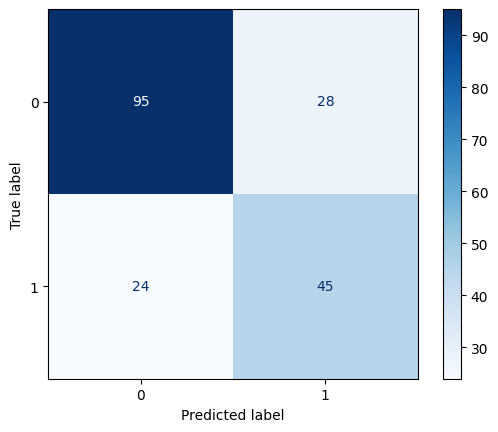


Best Model based on CV: Logistic Regression
Test Accuracy: 0.7292


In [71]:
best_cv_model = cv_results.loc[cv_results['Mean CV Accuracy'].idxmax()]
best_model_name = best_cv_model['Model']

preds_map = {
    "Logistic Regression": {
        'pred': logistic_pred,
        'acc': logistic_acc,
        'model': logistic_model
    },
    "K-Nearest Neighbors (KNN)": {
        'pred': knn_pred,
        'acc': knn_acc,
        'model': knn_model
    },
    "Support Vector Machine (SVM)": {
        'pred': svm_pred,
        'acc': svm_acc,
        'model': svm_model
    },
    "Kernel SVM": {
        'pred': kernel_svm_pred,
        'acc': kernel_svm_acc,
        'model': kernel_svm_model
    },
    "Naive Bayes": {
        'pred': nb_pred,
        'acc': nb_acc,
        'model': nb_model
    },
    "Decision Tree": {
        'pred': dt_pred,
        'acc': dt_acc,
        'model': dt_model
    },
    "Random Forest": {
        'pred': rf_pred,
        'acc': rf_acc,
        'model': rf_model
    }
}

best_model_obj = preds_map[best_model_name]['model']
cm = confusion_matrix(y_test, preds_map[best_model_name]['pred'])
plt.figure(figsize=(2, 2))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_obj.classes_)
display.plot(cmap='Blues')
plt.show()

# [[True Negatives (TN),  False Positives (FP)],
#  [False Negatives (FN), True Positives (TP)]]

# TP (True Positive): we predicted Positive, and it really was Positive
# TN (True Negative): we predicted Negative, and it really was Negative
# FP (False Positive): we predicted Positive, but it was actually Negative ("false alarm")
# FN (False Negative): we predicted Negative, but it was actually Positive ("we missed it")

print()
print(f"Best Model based on CV: {best_model_name}")
print(f"Test Accuracy: {preds_map[best_model_name]['acc']:.4f}")

# Classification report

In [72]:
print(classification_report(y_test, preds_map[best_model_name]['pred'], target_names=best_model_obj.classes_.astype(str)))

              precision    recall  f1-score   support

           0       0.80      0.77      0.79       123
           1       0.62      0.65      0.63        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192



**Precision** — *"Of everything I labeled Positive, how much did I actually get right?"*
$$Precision = \frac{TP}{TP + FP}$$
High precision means: when the model says "Positive", you can trust it. Low precision means the model raises a lot of false alarms.

**Recall (a.k.a. Sensitivity)** — *"Of everything that was truly Positive, how much did I manage to catch?"*
$$Recall = \frac{TP}{TP + FN}$$
High recall means the model rarely misses a real Positive case. Low recall means many real Positives slip through undetected.

**F1-score** — *the harmonic mean of Precision and Recall:*
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
The F1-score is useful when you want a single number that balances both Precision and Recall — it's especially informative when the class distribution is imbalanced, since it punishes models that do well on only one of the two metrics.